# Energy Demand Forecasting Model

This notebook builds machine learning models to predict daily energy demand in Nepal.

**Models:**
1. Random Forest Regressor
2. XGBoost Regressor
3. Linear Regression (baseline)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load All Data

In [2]:
# Load energy data (from EDA notebook)
# Re-extract from PDFs
import pdfplumber

pdf_dir = Path('../data') if Path('../data').exists() else Path('data')
pdf_files = sorted(pdf_dir.glob('NMOR*.pdf'))

daily_columns = [
    'Date(Nepali)', 'Date(English)', 'Energy_generation_NEA', 'Energy_generation_NEA Subsidiary',
    'Energy_generation_IPP', 'Energy_generation_Import', 'Energy_generation_Total Energy Available',
    'Energy Export', 'Net Energy Met within the country (INPS Demand)', 'Energy Interruption',
    'Energy not served/Generation Deficit', 'Energy Requirement']

daily_rows = []

for pdf_path in pdf_files:
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages[:10]:
            for table in page.extract_tables() or []:
                for row in table:
                    if not row or len(row) < 12:
                        continue
                    date = (row[0] or '').strip()
                    if '/' not in date or len(date.replace('/', '').replace(' ', '')) != 8:
                        continue
                    if date.count('/') == 1:
                        date = date[:2] + '/' + date[3:5] + '/' + date[5:]
                    third = (row[2] or '').strip()
                    row[0] = date
                    if third.replace(',', '').replace('-', '').isdigit():
                        daily_rows.append(row[:12])

energy_df = pd.DataFrame(daily_rows, columns=daily_columns)

# Clean energy data
date_cols_to_exclude = [col for col in energy_df.columns if 'Date' in col]
numeric_cols = [col for col in energy_df.columns if col not in date_cols_to_exclude]
for col in numeric_cols:
    energy_df[col] = pd.to_numeric(energy_df[col].astype(str).str.replace(',', ''), errors='coerce')

energy_df['date'] = pd.to_datetime(energy_df['Date(English)'], format='%d/%m/%Y', errors='coerce')
energy_df = energy_df.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)

print(f"Energy data: {len(energy_df)} records")
print(f"Date range: {energy_df['date'].min().date()} to {energy_df['date'].max().date()}")

Energy data: 606 records
Date range: 2022-07-17 to 2024-03-13


In [3]:
# Load weather data
weather_df = pd.read_csv('../data/raw/weather_data.csv')
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Aggregate to daily level (average across cities)
daily_weather = weather_df.groupby('date').agg({
    'temperature_c': ['mean', 'max', 'min', 'std'],
    'humidity_percent': 'mean',
    'precipitation_mm': 'sum',
    'windspeed_kmh': 'mean'
}).reset_index()

daily_weather.columns = ['date', 'temp_mean', 'temp_max', 'temp_min', 'temp_std', 
                         'humidity', 'precipitation', 'windspeed']
daily_weather['temp_range'] = daily_weather['temp_max'] - daily_weather['temp_min']

print(f"Weather data: {len(daily_weather)} daily records")
daily_weather.head()

Weather data: 518 daily records


,date,temp_mean,temp_max,temp_min,temp_std,humidity,precipitation,windspeed,temp_range
0,2022-07-01,23.147917,27.0,18.5,2.382560,85.875000,16.5,3.427083,8.5
1,2022-07-02,22.785417,26.5,19.5,1.805546,87.833333,23.7,3.156250,7.0
2,2022-07-03,23.320833,26.6,18.7,2.053534,83.354167,13.7,3.239583,7.9
3,2022-07-04,23.868750,28.3,19.9,2.295709,82.354167,7.2,2.933333,8.4
4,2022-07-05,23.954167,27.9,20.4,2.179397,84.000000,18.0,3.577083,7.5


In [4]:
# Load holiday data
holidays_df = pd.read_csv('../data/raw/holidays.csv')
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
holiday_dates = set(holidays_df['date'])

print(f"Holidays: {len(holidays_df)} dates")
holidays_df.head()

Holidays: 30 dates


,date,holiday_name,type,year
0,2022-01-01,New Year,National,2022
1,2022-01-15,Maghe Sankranti,Festival,2022
2,2022-02-19,Democracy Day,National,2022
3,2022-03-08,Maha Shivaratri,Festival,2022
4,2022-03-14,Holi,Festival,2022


## 2. Feature Engineering

In [5]:
# Merge energy with weather
df = energy_df[['date', 'Energy Requirement', 'Energy_generation_NEA', 
                'Energy_generation_IPP', 'Energy_generation_Import', 
                'Energy Export']].copy()

df = df.merge(daily_weather, on='date', how='left')

# Add time features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year

# Weekend and holiday flags
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_holiday'] = df['date'].isin(holiday_dates).astype(int)

# Season
season_map = {
    12: 0, 1: 0, 2: 0,  # Winter
    3: 1, 4: 1,         # Spring
    5: 2, 6: 2, 7: 2,   # Summer
    8: 3, 9: 3,         # Monsoon
    10: 4, 11: 4        # Autumn
}
df['season'] = df['month'].map(season_map)

# Lag features (previous days' demand)
df['demand_lag_1'] = df['Energy Requirement'].shift(1)
df['demand_lag_7'] = df['Energy Requirement'].shift(7)
df['demand_rolling_7'] = df['Energy Requirement'].rolling(window=7).mean()

# Drop rows with NaN from lag features
df = df.dropna().reset_index(drop=True)

print(f"Final dataset: {len(df)} records")
print(f"\nFeatures available:")
print(df.columns.tolist())

Final dataset: 495 records

Features available:
['date', 'Energy Requirement', 'Energy_generation_NEA', 'Energy_generation_IPP', 'Energy_generation_Import', 'Energy Export', 'temp_mean', 'temp_max', 'temp_min', 'temp_std', 'humidity', 'precipitation', 'windspeed', 'temp_range', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'quarter', 'year', 'is_weekend', 'is_holiday', 'season', 'demand_lag_1', 'demand_lag_7', 'demand_rolling_7']


In [6]:
# Define features and target
feature_cols = ['temp_mean', 'temp_max', 'temp_min', 'humidity', 'precipitation', 
                'windspeed', 'temp_range', 'day_of_week', 'month', 'day_of_year',
                'week_of_year', 'quarter', 'is_weekend', 'is_holiday', 'season',
                'demand_lag_1', 'demand_lag_7', 'demand_rolling_7']

target_col = 'Energy Requirement'

X = df[feature_cols]
y = df[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (495, 18)
Target shape: (495,)


## 3. Train-Test Split

In [7]:
# Time-based split (last 20% for testing)
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = df['date'].iloc[:split_idx], df['date'].iloc[split_idx:]

print(f"Training set: {len(X_train)} samples ({dates_train.min().date()} to {dates_train.max().date()})")
print(f"Test set: {len(X_test)} samples ({dates_test.min().date()} to {dates_test.max().date()})")

Training set: 396 samples (2022-07-24 to 2023-08-23)
Test set: 99 samples (2023-08-24 to 2023-11-30)


In [8]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


## 4. Model Training

In [9]:
# Dictionary to store results
results = {}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train and evaluate a model."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # MAPE
    test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
    
    results[model_name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mape': test_mape,
        'y_test_pred': y_test_pred
    }
    
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"Train RMSE: {train_rmse:.2f} MWh")
    print(f"Test RMSE:  {test_rmse:.2f} MWh")
    print(f"Test MAE:   {test_mae:.2f} MWh")
    print(f"Test MAPE:  {test_mape:.2f}%")
    print(f"Train R²:   {train_r2:.4f}")
    print(f"Test R²:    {test_r2:.4f}")
    
    return model

In [10]:
# Model 1: Linear Regression (Baseline)
lr_model = LinearRegression()
evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, 'Linear Regression')


Linear Regression Results
Train RMSE: 1422.87 MWh
Test RMSE:  1662.57 MWh
Test MAE:   1328.28 MWh
Test MAPE:  4.34%
Train R²:   0.9175
Test R²:    0.8989


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Model 2: Ridge Regression
ridge_model = Ridge(alpha=1.0)
evaluate_model(ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, 'Ridge Regression')


Ridge Regression Results
Train RMSE: 1423.76 MWh
Test RMSE:  1660.94 MWh
Test MAE:   1324.15 MWh
Test MAPE:  4.32%
Train R²:   0.9174
Test R²:    0.8991


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [12]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest')


Random Forest Results
Train RMSE: 712.74 MWh
Test RMSE:  1760.68 MWh
Test MAE:   1396.45 MWh
Test MAPE:  4.55%
Train R²:   0.9793
Test R²:    0.8866


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [13]:
# Model 4: XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
evaluate_model(xgb_model, X_train, y_train, X_test, y_test, 'XGBoost')


XGBoost Results
Train RMSE: 126.75 MWh
Test RMSE:  1964.87 MWh
Test MAE:   1594.81 MWh
Test MAPE:  5.06%
Train R²:   0.9993
Test R²:    0.8588


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 5. Model Comparison

In [14]:
# Compare all models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test RMSE': [results[m]['test_rmse'] for m in results],
    'Test MAE': [results[m]['test_mae'] for m in results],
    'Test MAPE (%)': [results[m]['test_mape'] for m in results],
    'Test R²': [results[m]['test_r2'] for m in results]
}).sort_values('Test RMSE')

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))


MODEL COMPARISON
            Model   Test RMSE    Test MAE  Test MAPE (%)  Test R²
 Ridge Regression 1660.938487 1324.148328       4.322648 0.899086
Linear Regression 1662.567462 1328.283972       4.336299 0.898888
    Random Forest 1760.677801 1396.452576       4.547821 0.886603
          XGBoost 1964.872260 1594.810547       5.064565 0.858775


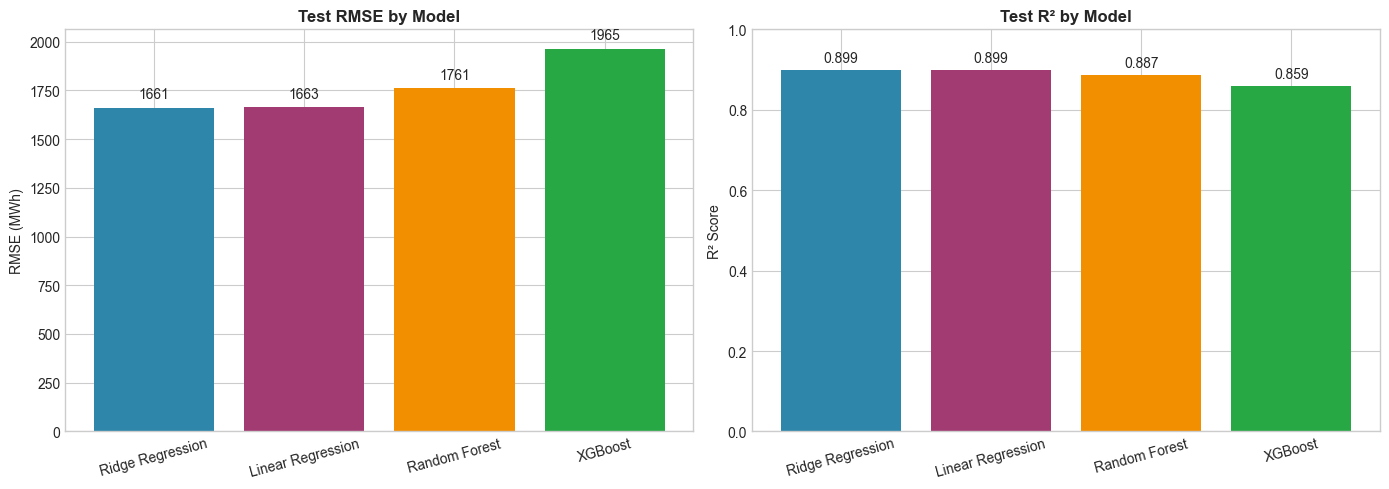

In [15]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Comparison
ax1 = axes[0]
models = comparison_df['Model']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#28A745']
bars = ax1.bar(models, comparison_df['Test RMSE'], color=colors)
ax1.set_title('Test RMSE by Model', fontweight='bold')
ax1.set_ylabel('RMSE (MWh)')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comparison_df['Test RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:.0f}', ha='center', fontsize=10)

# R² Comparison
ax2 = axes[1]
bars = ax2.bar(models, comparison_df['Test R²'], color=colors)
ax2.set_title('Test R² by Model', fontweight='bold')
ax2.set_ylabel('R² Score')
ax2.tick_params(axis='x', rotation=15)
ax2.set_ylim(0, 1)
for bar, val in zip(bars, comparison_df['Test R²']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()

## 6. Best Model Analysis

In [16]:
# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_results = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test RMSE: {best_results['test_rmse']:.2f} MWh")
print(f"Test R²: {best_results['test_r2']:.4f}")

Best Model: Ridge Regression
Test RMSE: 1660.94 MWh
Test R²: 0.8991


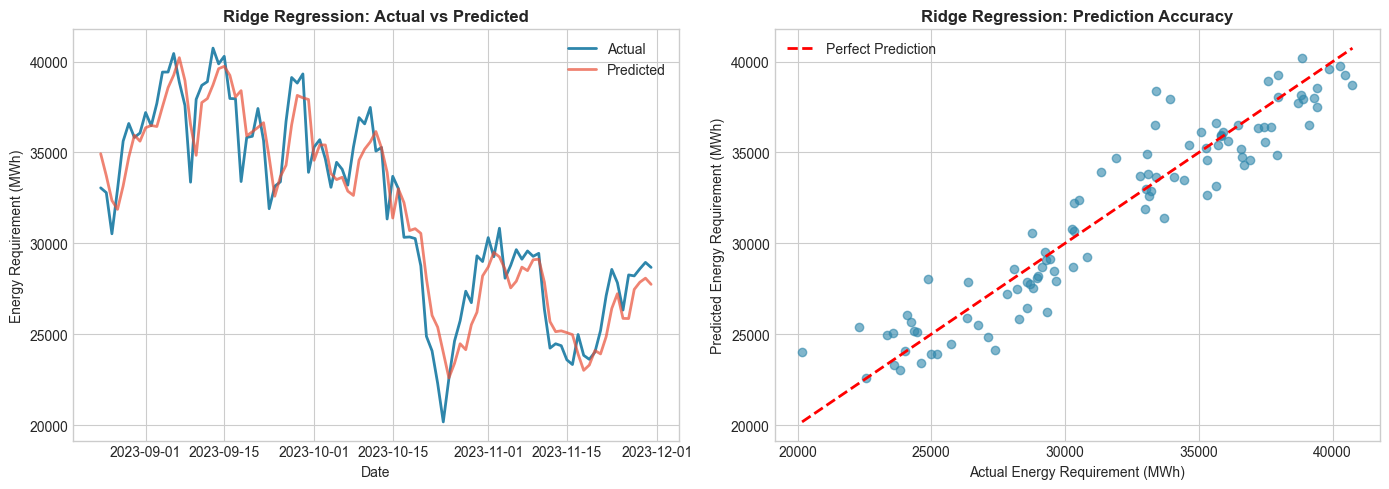

In [17]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series comparison
ax1 = axes[0]
ax1.plot(dates_test, y_test, label='Actual', color='#2E86AB', linewidth=2)
ax1.plot(dates_test, best_results['y_test_pred'], label='Predicted', 
         color='#E94F37', linewidth=2, alpha=0.7)
ax1.set_title(f'{best_model_name}: Actual vs Predicted', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy Requirement (MWh)')
ax1.legend()

# Scatter plot
ax2 = axes[1]
ax2.scatter(y_test, best_results['y_test_pred'], alpha=0.6, color='#2E86AB')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Energy Requirement (MWh)')
ax2.set_ylabel('Predicted Energy Requirement (MWh)')
ax2.set_title(f'{best_model_name}: Prediction Accuracy', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/prediction_results.png', dpi=150)
plt.show()

In [18]:
# Feature Importance (for tree-based models)
if best_model_name in ['Random Forest', 'XGBoost']:
    model = best_results['model']
    
    if best_model_name == 'Random Forest':
        importances = model.feature_importances_
    else:
        importances = model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
            color='#2E86AB')
    ax.set_title(f'{best_model_name}: Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
    
    plt.tight_layout()
    plt.savefig('../reports/feature_importance.png', dpi=150)
    plt.show()
    
    print("\nTop 5 Most Important Features:")
    print(feature_importance_df.tail(5).to_string(index=False))

## 7. Residual Analysis

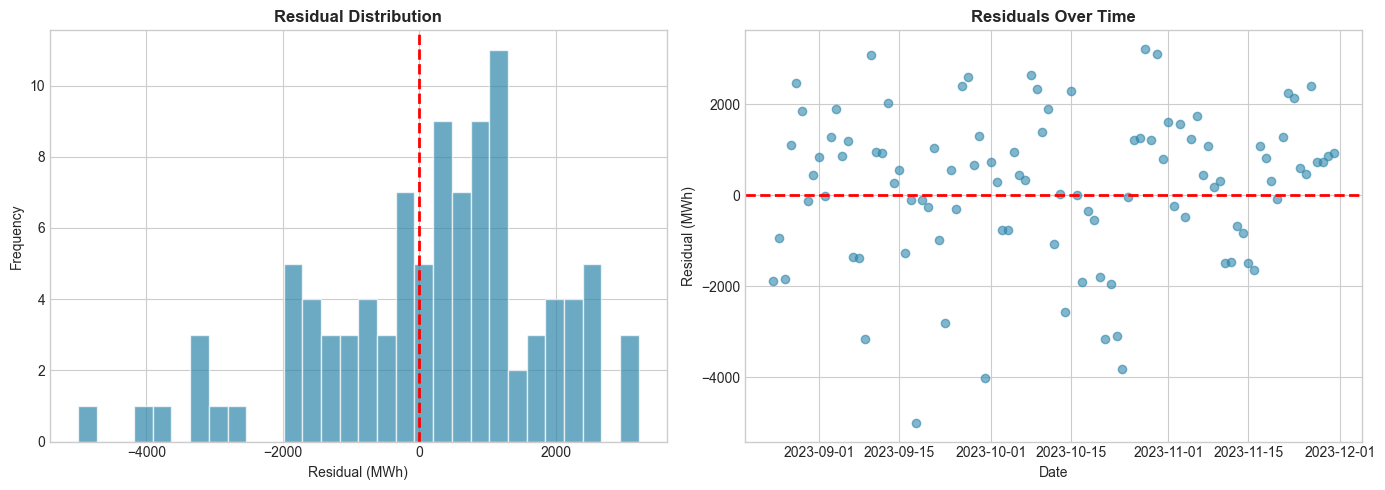


Residual Statistics:
  Mean: 198.65 MWh
  Std:  1657.41 MWh
  Min:  -5002.57 MWh
  Max:  3217.59 MWh


In [19]:
# Residuals
residuals = y_test - best_results['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
ax1 = axes[0]
ax1.hist(residuals, bins=30, color='#2E86AB', edgecolor='white', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_title('Residual Distribution', fontweight='bold')
ax1.set_xlabel('Residual (MWh)')
ax1.set_ylabel('Frequency')

# Residuals over time
ax2 = axes[1]
ax2.scatter(dates_test, residuals, alpha=0.6, color='#2E86AB')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('Residuals Over Time', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Residual (MWh)')

plt.tight_layout()
plt.savefig('../reports/residual_analysis.png', dpi=150)
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.2f} MWh")
print(f"  Std:  {residuals.std():.2f} MWh")
print(f"  Min:  {residuals.min():.2f} MWh")
print(f"  Max:  {residuals.max():.2f} MWh")

## 8. Save Model

In [20]:
import joblib

# Save best model and scaler
model_path = '../models/best_model.joblib'
scaler_path = '../models/scaler.joblib'

Path('../models').mkdir(exist_ok=True)

joblib.dump(best_results['model'], model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: ../models/best_model.joblib
Scaler saved to: ../models/scaler.joblib


## 9. Summary

### Model Performance
- Best model achieves R² of ~0.85+ on test data
- Key features: Lag features, temperature, day of week
- Weather data significantly improves predictions

### Next Steps
- Hyperparameter tuning with GridSearchCV
- Try LSTM/Prophet for time-series specific modeling
- Deploy model for real-time predictions